In [ ]:
%pip install nilearn pydantic rich -q --progress-bar off

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import pydantic
from typing import Literal
%config InlineBackend.figure_format = "retina"

from rich import pretty
pretty.install()

[`neuralset`](https://github.com/facebookresearch/neuroai) wraps `nilearn.signal.clean` in a tiny pydantic config object called `FmriCleaner`. If the five knobs (`detrend`, `standardize`, `high_pass` / `low_pass`, `ensure_finite`) are new to you, read [**`signal-clean`**](../nilearn-nilearn/signal-clean.ipynb) first — it builds the intuition from a synthetic signal. This notebook assumes that and focuses on what the *wrapper* adds:

- it's a **validated config object**, not a bare function call;
- it flips the data contract to **`(n_features, time)`** (nilearn wants `(time, n_features)`);
- and it guards the `clean()` call in a way that — per [**neuroai#130**](https://github.com/facebookresearch/neuroai/issues/130) — silently drops `ensure_finite` when the signal-processing knobs are off.

We reproduce the class inline so the guard is visible and the notebook runs without the full (torch-heavy) `neuralset` install.

In [3]:
# Reproduced verbatim from neuralset.extractors.neuro.FmriCleaner (neuralset 0.2.2)
# so this notebook is self-contained. Source: github.com/facebookresearch/neuroai

class FmriCleaner(pydantic.BaseModel):
    """Configuration for fMRI signal cleaning."""

    model_config = pydantic.ConfigDict(extra="forbid")
    standardize: Literal["zscore_sample", "zscore", "psc"] | bool = "zscore_sample"
    detrend: bool = True
    high_pass: float | None = None
    low_pass: float | None = None
    filter: Literal["butterworth", "cosine"] | None = None
    ensure_finite: bool = True

    def clean(self, data: np.ndarray, t_r: float) -> np.ndarray:
        if (
            self.detrend
            or self.standardize
            or (self.high_pass is not None)
            or (self.low_pass is not None)
        ):
            import nilearn.signal

            data = data.T  # set time as first dim
            shape = data.shape
            data = nilearn.signal.clean(
                data.reshape(shape[0], -1),
                t_r=t_r,
                standardize=self.standardize,
                high_pass=self.high_pass,
                low_pass=self.low_pass,
                filter=self.filter,
                detrend=self.detrend,
                ensure_finite=self.ensure_finite,
            )
            data = data.reshape(shape).T
        return data

## A config object, not a function

`FmriCleaner` is a `pydantic.BaseModel`: every field is typed and validated, defaults are declared once, and `extra="forbid"` means a misspelled option is rejected at construction instead of silently ignored. This is the pattern `neuralset` uses for all its configs.

In [4]:
print("fields & defaults:")
for name, field in FmriCleaner.model_fields.items():
    print(f"  {name:<14} default={field.default!r}")

print("\ndefault config:", FmriCleaner().model_dump())

# extra="forbid" -> a typo is a hard error, not a silent no-op
try:
    FmriCleaner(detrendd=True)          # note the typo
except pydantic.ValidationError as e:
    print("\nrejected unknown field 'detrendd':", e.errors()[0]["type"])

fields & defaults:
  standardize    default='zscore_sample'
  detrend        default=True
  high_pass      default=None
  low_pass       default=None
  filter         default=None
  ensure_finite  default=True

default config: {'standardize': 'zscore_sample', 'detrend': True, 'high_pass': None, 'low_pass': None, 'filter': None, 'ensure_finite': True}

rejected unknown field 'detrendd': extra_forbidden


## The data contract: `(n_features, time)`

`nilearn.signal.clean` expects **time first** — `(time, n_features)`. `FmriCleaner.clean(data, t_r)` flips that: it takes **`(n_features, time)`** (the layout the rest of `neuralset` uses), transposes internally, cleans, then transposes back — so shape in equals shape out, for any number of feature dimensions. `t_r` is the repetition time in seconds (`1 / frequency`).

We build the same synthetic voxel as the `signal-clean` notebook — `baseline + drift + slow wave + fast noise` — and plant one `NaN`, because non-finite values are normal in fMRI (masks, registration, surface projection all leave them behind).

In [5]:
t_r = 2.0                       # seconds per sample (a typical fMRI TR)
n   = 200
t   = np.arange(n) * t_r

truth  = 100 + 0.05*t + 3*np.sin(2*np.pi*0.02*t) + 1*np.sin(2*np.pi*0.20*t)
signal = truth.copy().reshape(1, -1).astype(np.float32)   # (n_features=1, time)
signal[0, 50] = np.nan                                     # one planted NaN

print("signal shape (features, time):", signal.shape, " finite:", np.isfinite(signal).all())

# shape is preserved for any number of feature dims:
multi = np.random.randn(5, n).astype(np.float32)
print("multi-voxel in:", multi.shape, "-> out:", FmriCleaner().clean(multi, t_r).shape)

signal shape (features, time): (1, 200)  finite: False


multi-voxel in: (5, 200) -> out: (5, 200)


## The guard — and the bug (#130)

The whole issue lives in `clean()`'s opening `if`: it calls `nilearn.signal.clean` **only** when a signal-processing knob (`detrend` / `standardize` / a filter) is on. But `ensure_finite` is forwarded *inside* that call — so when every signal-processing knob is off, the call is skipped and `ensure_finite` goes with it, **even when you set it to `True`**.

Watch the same planted `NaN` (sample 50) under three configs:

In [6]:
def describe(name, x):
    x = np.asarray(x).ravel()
    print(f"{name:<48} finite={str(np.isfinite(x).all()):<5} sample50={x[50]:8.3f}")

describe("default (detrend+zscore)", FmriCleaner().clean(signal.copy(), t_r))
describe("detrend=F, standardize=F", FmriCleaner(detrend=False, standardize=False).clean(signal.copy(), t_r))
describe("detrend=F, standardize=F, ensure_finite=True", FmriCleaner(detrend=False, standardize=False, ensure_finite=True).clean(signal.copy(), t_r))

default (detrend+zscore)                         finite=True  sample50= -13.451
detrend=F, standardize=F                         finite=False sample50=     nan
detrend=F, standardize=F, ensure_finite=True     finite=False sample50=     nan


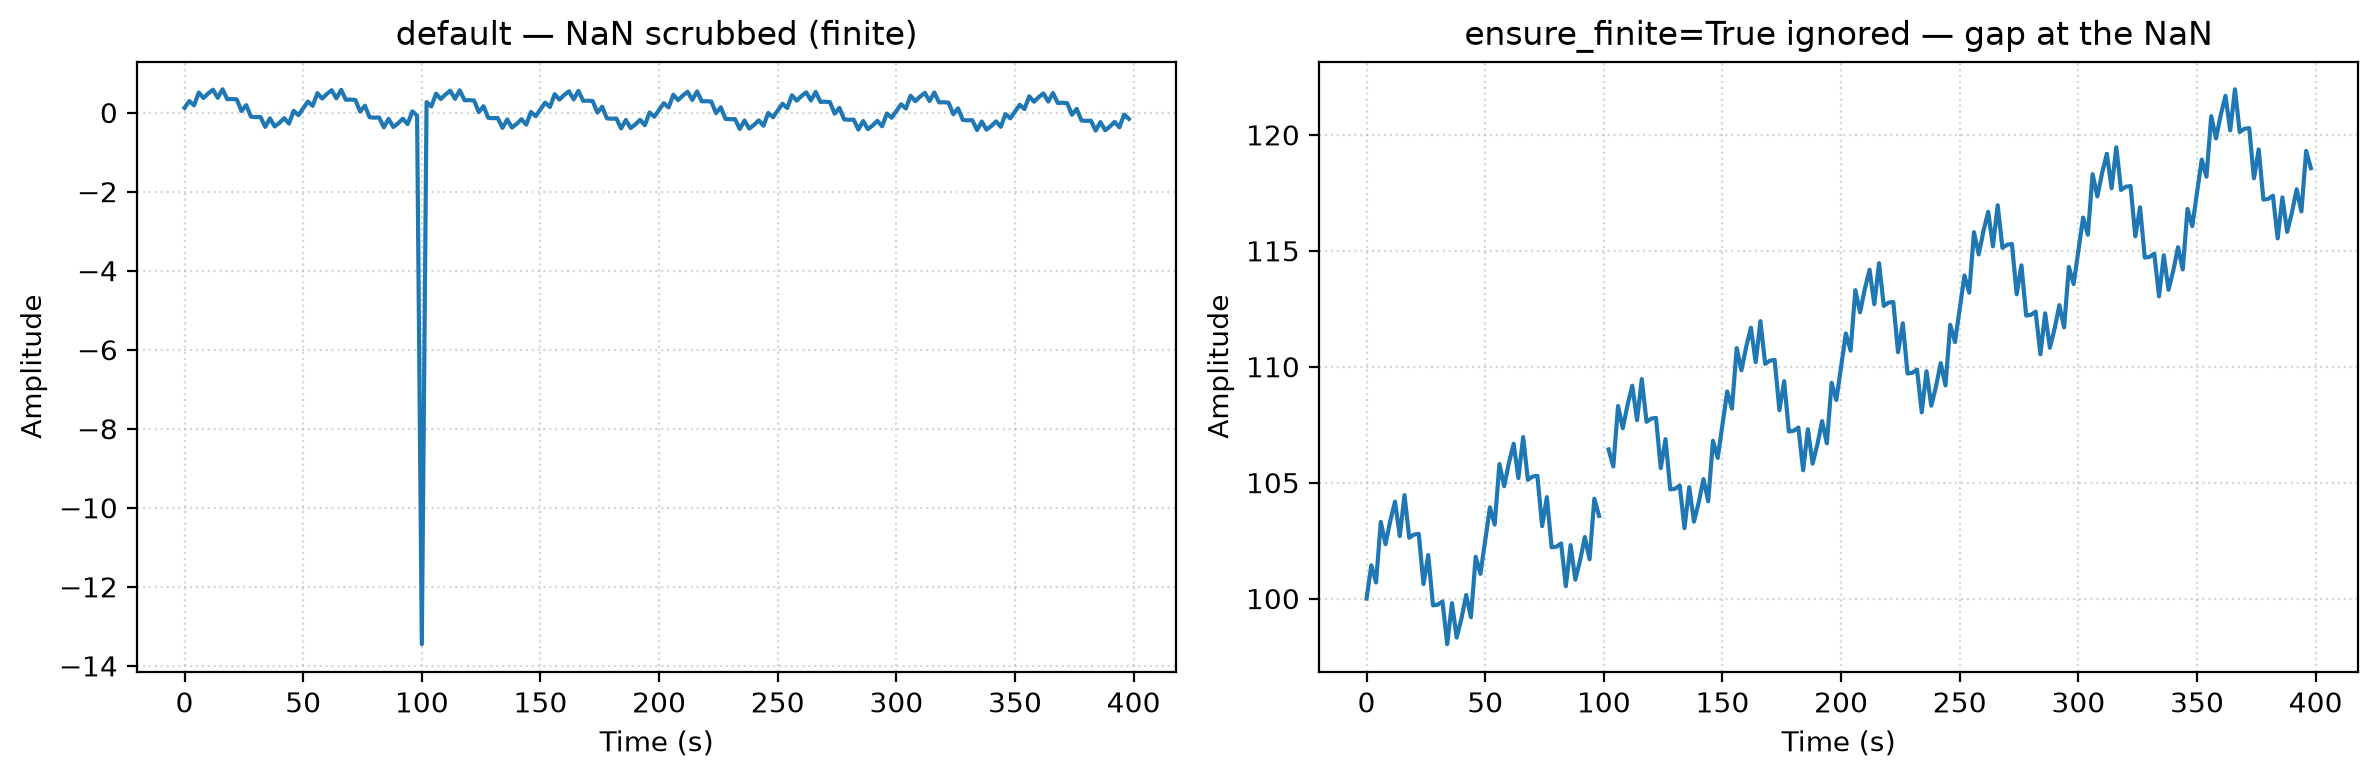

In [7]:
default_out = FmriCleaner().clean(signal.copy(), t_r)
leaked_out  = FmriCleaner(detrend=False, standardize=False, ensure_finite=True).clean(signal.copy(), t_r)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(t, default_out.ravel())
ax1.set_title("default — NaN scrubbed (finite)")
ax1.set_xlabel("Time (s)"); ax1.set_ylabel("Amplitude"); ax1.grid(True, linestyle=":", alpha=0.5)

ax2.plot(t, leaked_out.ravel())
ax2.set_title("ensure_finite=True ignored — gap at the NaN")
ax2.set_xlabel("Time (s)"); ax2.set_ylabel("Amplitude"); ax2.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

## The takeaway

`ensure_finite` is **data hygiene** — a different category from the signal-processing knobs (see [`signal-clean`](../nilearn-nilearn/signal-clean.ipynb) for why). The wrapper accidentally couples the two: by nesting `ensure_finite` inside a guard that only fires for `detrend` / `standardize` / filters, it turns "raw signal, just keep it finite" (`detrend=False, standardize=False, ensure_finite=True`) into "raw signal, `NaN`s and all" — and those `NaN`s detonate the moment a downstream model or fit touches them.

The fix is to honour `ensure_finite` independently of the other knobs — either by adding it to the guard, or by handling finite-replacement explicitly when the guard is otherwise false. That design choice is the next step.